In [2]:
import os, torch, torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
BASE       = "/home/fateennr/Codes/ML_Shikhbo/ml-project-swe/Plant-doc-dataset/processed"
train_path = os.path.join(BASE, "train")
val_path   = os.path.join(BASE, "val")
test_path  = os.path.join(BASE, "test")

classes      = sorted([c for c in os.listdir(train_path)
                       if os.path.isdir(os.path.join(train_path, c))])
class_to_idx = {c: i for i, c in enumerate(classes)}
num_classes  = len(classes)

print(f"Total classes: {num_classes}")
print(classes)


Total classes: 6
['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [4]:
class PlantDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        for cls in classes:
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir): continue
            for f in os.listdir(cls_dir):
                if f.endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, f), class_to_idx[cls]))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    ),
])

train_ds = PlantDataset(train_path, transform)
val_ds   = PlantDataset(val_path,   transform)
test_ds  = PlantDataset(test_path,  transform)

BATCH_SIZE   = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Train: 4553 | Val: 58 | Test: 56


In [6]:
model = models.densenet121(weights='IMAGENET1K_V1')

# Replace the last layer to match our 27 disease classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier.in_features, num_classes)
)

model = model.to(device)
print(model.classifier)   # confirm the new head


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=6, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing reduces overconfidence
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Early Stopping ────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=6, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_acc   = 0

    def __call__(self, val_acc):
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.counter  = 0
            return False   # don't stop
        else:
            self.counter += 1
            print(f"  ⏳ EarlyStopping counter: {self.counter}/{self.patience}")
            return self.counter >= self.patience  # True = stop

early_stop = EarlyStopping(patience=6)

print("Loss / Optimizer / Scheduler / EarlyStopping ready")
print(f"   lr            : {optimizer.param_groups[0]['lr']}")
print(f"   weight_decay  : {optimizer.param_groups[0]['weight_decay']}")
print(f"   label_smoothing: 0.1")


Loss / Optimizer / Scheduler / EarlyStopping ready
   lr            : 3e-05
   weight_decay  : 0.001
   label_smoothing: 0.1


In [8]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


In [12]:
EPOCHS       = 30
best_val_acc = 0
save_path    = 'densenet121_best.pth'
ckpt_path    = 'densenet121_checkpoint.pth'
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

# ── Auto-resume if checkpoint exists ─────────────────────────────────────
start_epoch = 1
if os.path.exists(ckpt_path):
    checkpoint   = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scheduler.load_state_dict(checkpoint['scheduler_state'])
    start_epoch  = checkpoint['epoch'] + 1
    best_val_acc = checkpoint['best_val_acc']
    history      = checkpoint['history']
    early_stop.best_acc = best_val_acc
    print(f"Resumed from epoch {checkpoint['epoch']}")
    print(f"   Best val acc so far : {best_val_acc*100:.2f}%")
else:
    print("Starting fresh training")

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    vl_loss, vl_acc = evaluate(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), save_path)
        print(f" Best model saved → val acc: {vl_acc*100:.2f}%")

    # Save checkpoint every epoch (for resuming)
    torch.save({
        'epoch':           epoch,
        'model_state':     model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scheduler_state': scheduler.state_dict(),
        'best_val_acc':    best_val_acc,
        'history':         history,
    }, ckpt_path)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc*100:.2f}% | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    # Early stopping check
    if early_stop(vl_acc):
        print(f"\nEarly stopping triggered at epoch {epoch}")
        print(f"   Val accuracy hasn't improved for {early_stop.patience} epochs")
        break

print(f"\n🏁 Training complete!")
print(f"   Best Validation Accuracy : {best_val_acc*100:.2f}%")


Starting fresh training


 Best model saved → val acc: 60.34%
Epoch 01/30 | Train Loss: 1.4577  Acc: 47.57% | Val Loss: 1.2109  Acc: 60.34% | LR: 2.98e-05


 Best model saved → val acc: 65.52%
Epoch 02/30 | Train Loss: 0.9667  Acc: 76.85% | Val Loss: 1.0815  Acc: 65.52% | LR: 2.93e-05


 Best model saved → val acc: 70.69%
Epoch 03/30 | Train Loss: 0.6964  Acc: 91.06% | Val Loss: 1.0453  Acc: 70.69% | LR: 2.84e-05


 Best model saved → val acc: 74.14%
Epoch 04/30 | Train Loss: 0.5467  Acc: 97.56% | Val Loss: 1.0635  Acc: 74.14% | LR: 2.72e-05


...

Epoch 06/30 | Train Loss: 0.4695  Acc: 99.71% | Val Loss: 1.0939  Acc: 72.41% | LR: 2.40e-05
  ⏳ EarlyStopping counter: 2/6


Epoch 07/30 | Train Loss: 0.4635  Acc: 99.91% | Val Loss: 1.1322  Acc: 70.69% | LR: 2.21e-05
  ⏳ EarlyStopping counter: 3/6


Epoch 08/30 | Train Loss: 0.4580  Acc: 99.96% | Val Loss: 1.1806  Acc: 67.24% | LR: 2.00e-05
  ⏳ EarlyStopping counter: 4/6


Epoch 09/30 | Train Loss: 0.4542  Acc: 99.98% | Val Loss: 1.1878  Acc: 72.41% | LR: 1.78e-05
  ⏳ EarlyStopping counter: 5/6


Epoch 10/30 | Train Loss: 0.4526  Acc: 100.00% | Val Loss: 1.1859  Acc: 67.24% | LR: 1.55e-05
  ⏳ EarlyStopping counter: 6/6

Early stopping triggered at epoch 10
   Val accuracy hasn't improved for 6 epochs

🏁 Training complete!
   Best Validation Accuracy : 74.14%


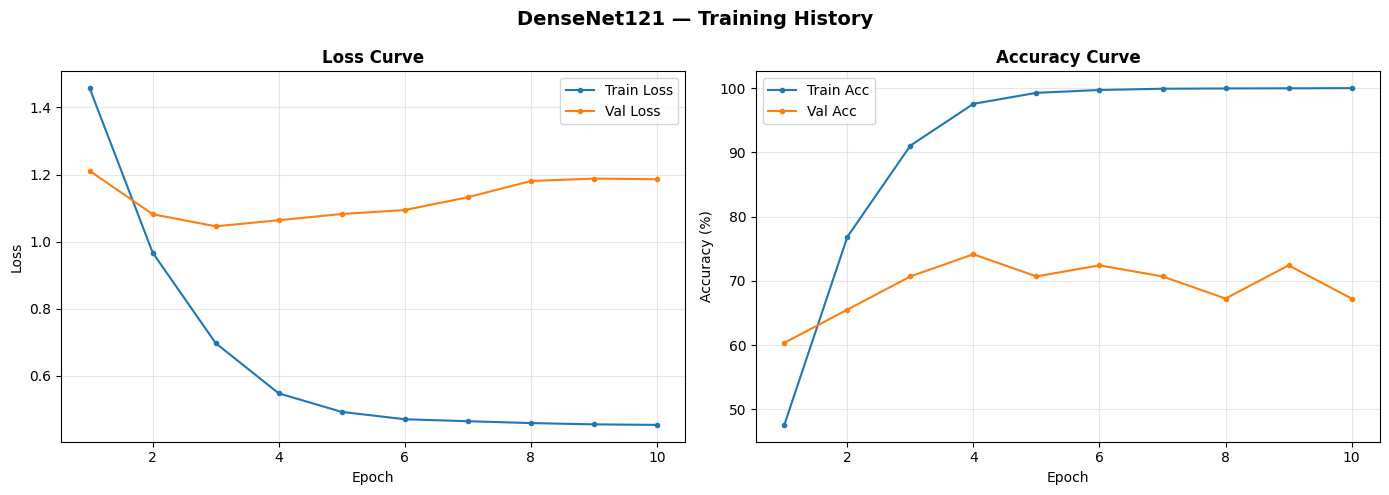

In [14]:
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x, history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   marker='o', markersize=3)
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x, [a*100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=3)
axes[1].plot(x, [a*100 for a in history['val_acc']],   label='Val Acc',   marker='o', markersize=3)
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DenseNet121 — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


In [15]:
model.load_state_dict(torch.load(save_path, map_location=device))

all_preds, all_labels_list = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        outputs = model(imgs.to(device))
        preds   = outputs.argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels_list.extend(labels.tolist())

test_acc = accuracy_score(all_labels_list, all_preds)
print(f"\n✅ DenseNet121 Test Accuracy: {test_acc*100:.2f}%")
print(f"   Best Val Accuracy        : {best_val_acc*100:.2f}%")

print("\n── Classification Report ──────────────────────")
print(classification_report(all_labels_list, all_preds, target_names=classes))


Testing: 100%|██████████| 2/2 [00:00<00:00,  9.31it/s]


✅ DenseNet121 Test Accuracy: 48.21%
   Best Val Accuracy        : 74.14%

── Classification Report ──────────────────────
                        precision    recall  f1-score   support

        Bacterial Spot       0.20      0.22      0.21         9
          Early Blight       0.38      0.38      0.38         8
               Healthy       0.50      0.67      0.57         6
           Late Blight       0.62      0.45      0.53        11
    Septoria Leaf Spot       0.53      0.53      0.53        15
Yellow Leaf Curl Virus       0.71      0.71      0.71         7

              accuracy                           0.48        56
             macro avg       0.49      0.49      0.49        56
          weighted avg       0.49      0.48      0.48        56



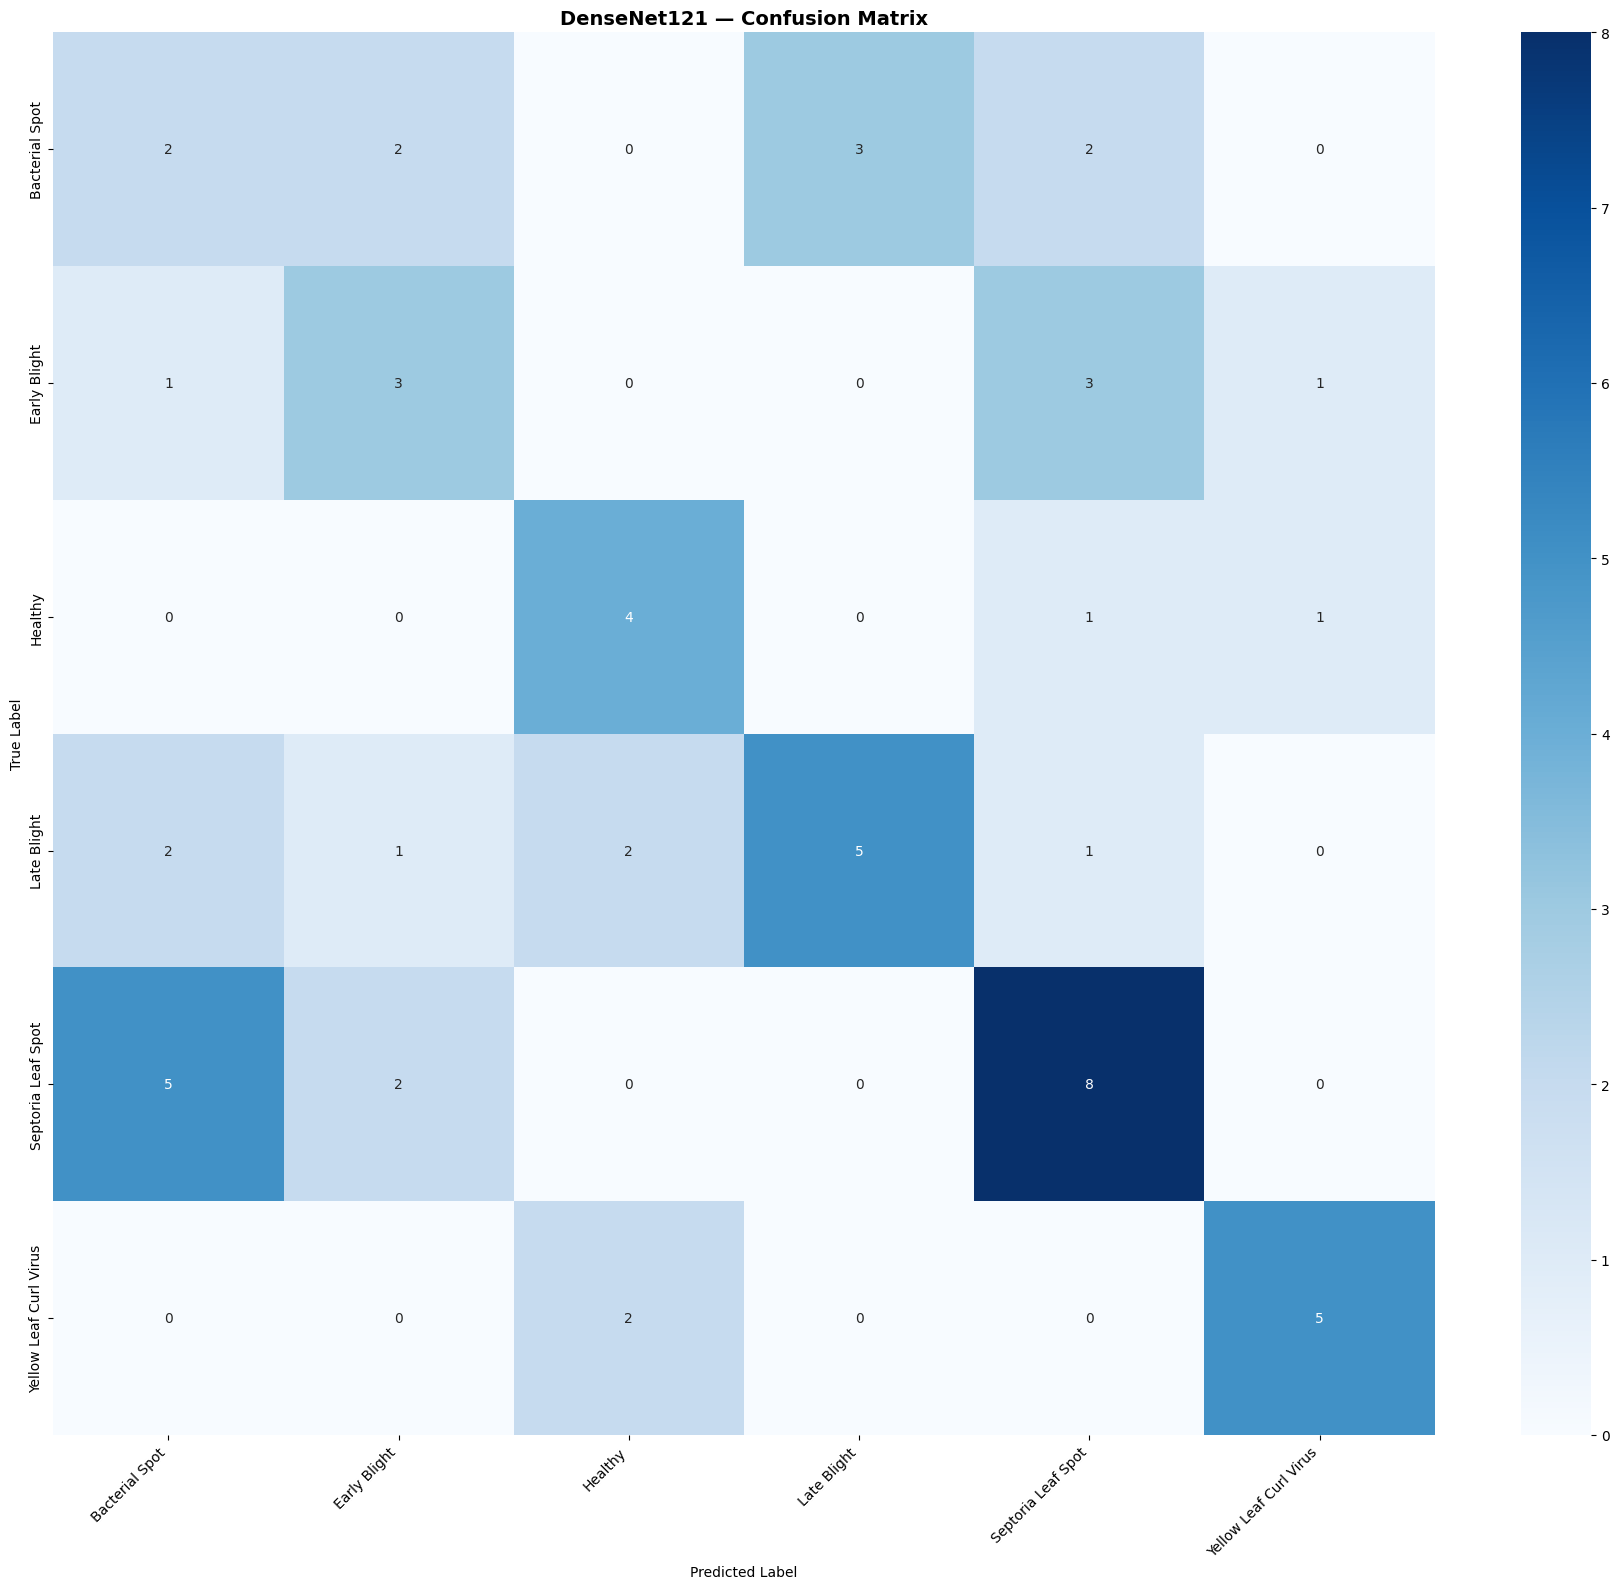

In [16]:
cm = confusion_matrix(all_labels_list, all_preds)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title('DenseNet121 — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
